In [1]:
import pandas as pd
import os
import glob
import CBE_utils as CBE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import importlib
importlib.reload(CBE)

<module 'CBE_utils' from '/home/schmied.christopher/FMP_Docs/Projects/eu_os_ecbl_qc/notebooks/CBE_utils.py'>

In [2]:
input_path = "/media/schmied.christopher/T7 Shield/Datasets/ECBL_IMTM/processed/"
output_path = input_path

results_path = "/media/schmied.christopher/T7 Shield/Datasets/ECBL_IMTM/results/"

In [3]:
site_specific_path = os.path.join(input_path, "IMTM")
     
# load raw data
pattern = "[A-Z]*_R[1-4].csv"
file_list = glob.glob(site_specific_path + os.sep + '*' + os.sep + pattern, recursive=True)

file_df = pd.DataFrame({'filepath': file_list})

# Extract information using regex
pattern = r'(\d{4}-\d{2}-\d{2})_([A-Z]\d+[A-Z]?)_(R\d+)'

file_df[['batch_date', 'plate_name', 'replicate']] = file_df['filepath'].str.extract(pattern)

print(file_df)

file_df['batch_date'] = pd.to_datetime(file_df['batch_date'])

file_df['batch_date_yymmdd'] = file_df['batch_date'].dt.strftime('%y%m%d')

                                              filepath  batch_date plate_name  \
0    /media/schmied.christopher/T7 Shield/Datasets/...  2025-04-11      A1292   
1    /media/schmied.christopher/T7 Shield/Datasets/...  2025-04-15      A1292   
2    /media/schmied.christopher/T7 Shield/Datasets/...  2025-04-18      A1292   
3    /media/schmied.christopher/T7 Shield/Datasets/...  2025-04-23      A1292   
4    /media/schmied.christopher/T7 Shield/Datasets/...  2025-04-11      A1293   
..                                                 ...         ...        ...   
389  /media/schmied.christopher/T7 Shield/Datasets/...         NaN        NaN   
390  /media/schmied.christopher/T7 Shield/Datasets/...         NaN        NaN   
391  /media/schmied.christopher/T7 Shield/Datasets/...         NaN        NaN   
392  /media/schmied.christopher/T7 Shield/Datasets/...         NaN        NaN   
393  /media/schmied.christopher/T7 Shield/Datasets/...         NaN        NaN   

    replicate  
0          

In [4]:
def read_reduced_file(file_list):

    Data = []

    # Read in the file dataframes 
    for file in file_list:
        
        plate_map_name = os.path.splitext(os.path.basename(file))[0]
        
        try:
            
            Data_Temp = pd.read_csv(file)
            row_count = Data_Temp.shape[0]
            
            print(f"File: {plate_map_name} has {row_count} rows")
            
            Data.append(Data_Temp)
                
        except Exception as e:
            
            print(f"Error reading file {plate_map_name}: {e}")
            
            
    ### concat all files together
    plates_aggregated = pd.concat(Data)
    plates_aggregated = plates_aggregated.reset_index(drop = True)

    print("Aggregated Data has shape ", plates_aggregated.shape)

    cols_to_keep = [
        "Metadata_Batch",
        "Metadata_staining_date",
        "Metadata_Plate",
        "Metadata_Well_randomized",
        "Metadata_Object_Count",
        "Metadata_plate_name",
        "Metadata_replicate_number",
        "Metadata_plate_map_name",
        "Metadata_Well",
        "Metadata_RoughID"
    ]

    plates_aggregated_reduced = plates_aggregated[cols_to_keep].copy()

    # get row and column values 
    plates_aggregated_reduced_copy = plates_aggregated_reduced .copy()

    # Well like "A01" -> row="A", col=1
    plates_aggregated_reduced_copy["row"] = plates_aggregated_reduced_copy["Metadata_Well"].str[0]                 # "A"
    plates_aggregated_reduced_copy["col"] = plates_aggregated_reduced_copy["Metadata_Well"].str[1:].astype(int)    # "01" -> 1

    return plates_aggregated_reduced_copy

In [18]:
batches = ["241101", 
           "241106", 
           "241108", 
           "241115", 
           "241128", 
           "241129", 
           "241204", 
           "250514", 
           "250516", 
           "250521", 
           "250522", 
           "250528",
           "251022",
           "251113",
           "251118",
           "251210",
           "251212"]

batches_file_df = file_df[file_df["batch_date_yymmdd"].astype(str).isin(batches)]
batches_list = batches_file_df["filepath"].dropna().tolist()

batches_df = read_reduced_file(batches_list)

File: A1303_R1 has 384 rows
File: A1303_R2 has 384 rows
File: A1303_R3 has 384 rows
File: A1303_R4 has 384 rows
File: A1304_R1 has 384 rows
File: A1304_R2 has 384 rows
File: A1304_R3 has 383 rows
File: A1304_R4 has 384 rows
File: A1305_R1 has 384 rows
File: A1305_R2 has 384 rows
File: A1305_R3 has 384 rows
File: A1305_R4 has 384 rows
File: A1306_R1 has 384 rows
File: A1306_R2 has 384 rows
File: A1306_R2 has 384 rows
File: A1306_R3 has 384 rows
File: A1306_R3 has 384 rows
File: A1306_R4 has 384 rows
File: A1307_R1 has 384 rows
File: A1307_R2 has 384 rows
File: A1307_R3 has 384 rows
File: A1307_R4 has 384 rows
File: A1308_R1 has 384 rows
File: A1308_R2 has 384 rows
File: A1308_R3 has 384 rows
File: A1308_R4 has 384 rows
File: A1309_R1 has 384 rows
File: A1309_R2 has 384 rows
File: A1309_R3 has 384 rows
File: A1309_R4 has 384 rows
File: A1310_R1 has 384 rows
File: A1310_R2 has 384 rows
File: A1310_R4 has 384 rows
File: C1236_R2 has 384 rows
File: C1236_R4 has 384 rows
File: C1248_R4 has 3

In [19]:
# get good min max for the same color scale across all tested plates
color_min = batches_df["Metadata_Object_Count"].min()
color_max = batches_df["Metadata_Object_Count"].max()

In [20]:
def plot_plate_heatmaps_all_plates(
    df,
    vmin=None,
    vmax=None,
    plate_col="Metadata_plate_name",
    rep_col="Metadata_replicate_number",
    batch_col="Metadata_staining_date",
    row_col="row",
    col_col="col",
    value_col="Metadata_Object_Count",
    replicates=("R1", "R2", "R3", "R4"),
):
    row_order = list("ABCDEFGHIJKLMNOP")  # 16
    col_order = list(range(1, 25))        # 24

    # Ensure replicate ordering (so sorting works even if it's a categorical)
    d = df.copy()
    d[rep_col] = d[rep_col].astype(str)
    d[plate_col] = d[plate_col].astype(str)

    # Sort by plate then replicate (R1..R4)
    rep_rank = {r: i for i, r in enumerate(replicates)}
    d["_rep_rank"] = d[rep_col].map(rep_rank).fillna(999).astype(int)
    d = d.sort_values([plate_col, "_rep_rank"])

    for plate, dplate in d.groupby(plate_col, sort=False):
        fig, axes = plt.subplots(1, len(replicates), figsize=(4 * len(replicates), 3), constrained_layout=True)
        axes = np.atleast_1d(axes).ravel()

        last_im = None

        for ax, rep in zip(axes, replicates):
            drep = dplate[dplate[rep_col] == rep]

            if drep.empty:
                # Keep panel but show it's missing
                ax.set_title(f"{rep} (missing)")
                ax.set_xticks([])
                ax.set_yticks([])
                ax.axis("off")
                continue

            grid = (
                drep.pivot(index=row_col, columns=col_col, values=value_col)
                    .reindex(index=row_order, columns=col_order)
            )

            im = ax.imshow(grid.to_numpy(), vmin=vmin, vmax=vmax, aspect="auto", origin="upper")
            last_im = im

            # Get batch (if multiple, show the first; adjust if you prefer "unique list")
            batch = drep[batch_col].iloc[0] if batch_col in drep.columns else "NA"
            
            ax.text(
                0.01, 1.02,
                f"batch: {batch} | plate: {plate} | rep: {rep}",
                transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=8
            )

            ax.set_yticks(range(len(row_order)))
            ax.set_yticklabels(row_order)

            ax.set_xticks(range(len(col_order)))
            ax.set_xticklabels([f"{c:02d}" for c in col_order], rotation=90)

        if last_im is not None:
            cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.85)
            cbar.set_label(value_col)

        fig.suptitle(f"Object count heatmaps — {plate}", y=1.05, fontsize=12)
        plt.show()

    # cleanup helper column
    # (if you don't want side effects, keep it in the copy `d` only like here)

In [21]:
def plot_plate_heatmaps_per_batch(
    df,
    vmin=None,
    vmax=None,
    plate_col="Metadata_plate_name",
    rep_col="Metadata_replicate_number",
    batch_col="Metadata_staining_date",
    row_col="row",
    col_col="col",
    value_col="Metadata_Object_Count",
    max_cols=6,
):
    """
    Plot per batch (one figure per batch). Within each batch, plot ALL plates.
    For each plate, plot all replicates that exist IN THAT BATCH for that plate.
    No aggregation, no dropping: we avoid pivot duplicates by subsetting to (batch, plate, rep).

    Layout:
      - Each subplot = one (plate, replicate) heatmap
      - Title/annotation includes batch, plate, replicate
    """
    import math
    import numpy as np
    import matplotlib.pyplot as plt

    row_order = list("ABCDEFGHIJKLMNOP")  # 16
    col_order = list(range(1, 25))        # 24

    d = df.copy()
    d[plate_col] = d[plate_col].astype(str)
    d[rep_col] = d[rep_col].astype(str)
    if batch_col in d.columns:
        d[batch_col] = d[batch_col].astype(str)
    else:
        d[batch_col] = "NA"

    # stable ordering
    d = d.sort_values([batch_col, plate_col, rep_col])

    for batch, dbatch in d.groupby(batch_col, sort=False):
        # Build list of panels: each is (plate, rep) present in this batch
        panels = (
            dbatch[[plate_col, rep_col]]
            .dropna()
            .drop_duplicates()
            .sort_values([plate_col, rep_col])
            .itertuples(index=False, name=None)
        )
        panels = list(panels)

        if len(panels) == 0:
            continue

        n = len(panels)
        ncols = min(max_cols, n)
        nrows = math.ceil(n / ncols)

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(4.0 * ncols, 3.3 * nrows),
            constrained_layout=True
        )
        axes = np.atleast_1d(axes).ravel()

        last_im = None

        for i, (plate, rep) in enumerate(panels):
            ax = axes[i]
            drep = dbatch[(dbatch[plate_col] == plate) & (dbatch[rep_col] == rep)]

            if drep.empty:
                ax.axis("off")
                continue

            # If still not unique, there is another real dimension (e.g., site/image_set)
            # We do NOT aggregate or drop; we just flag it so you know to facet further.
            if drep.duplicated(subset=[row_col, col_col]).any():
                ax.set_title("non-unique wells\n(add another facet)", fontsize=9)
                ax.text(
                    0.01, 1.02,
                    f"batch: {batch} | plate: {plate} | rep: {rep}",
                    transform=ax.transAxes,
                    ha="left", va="bottom",
                    fontsize=8
                )
                ax.set_xticks([]); ax.set_yticks([])
                ax.axis("off")
                continue

            grid = (
                drep.pivot(index=row_col, columns=col_col, values=value_col)
                    .reindex(index=row_order, columns=col_order)
            )

            im = ax.imshow(grid.to_numpy(), vmin=vmin, vmax=vmax, aspect="auto", origin="upper")
            last_im = im

            ax.text(
                0.01, 1.02,
                f"batch: {batch} | plate: {plate} | rep: {rep}",
                transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=8
            )

            ax.set_yticks(range(len(row_order)))
            ax.set_yticklabels(row_order)

            ax.set_xticks(range(len(col_order)))
            ax.set_xticklabels([f"{c:02d}" for c in col_order], rotation=90)

        # turn off unused axes
        for j in range(n, len(axes)):
            axes[j].axis("off")

        if last_im is not None:
            cbar = fig.colorbar(last_im, ax=axes[:n].tolist(), shrink=0.85)
            cbar.set_label(value_col)

        fig.suptitle(f"Heatmaps — batch {batch} (all plates/replicates in batch)", y=1.02, fontsize=12)
        plt.show()

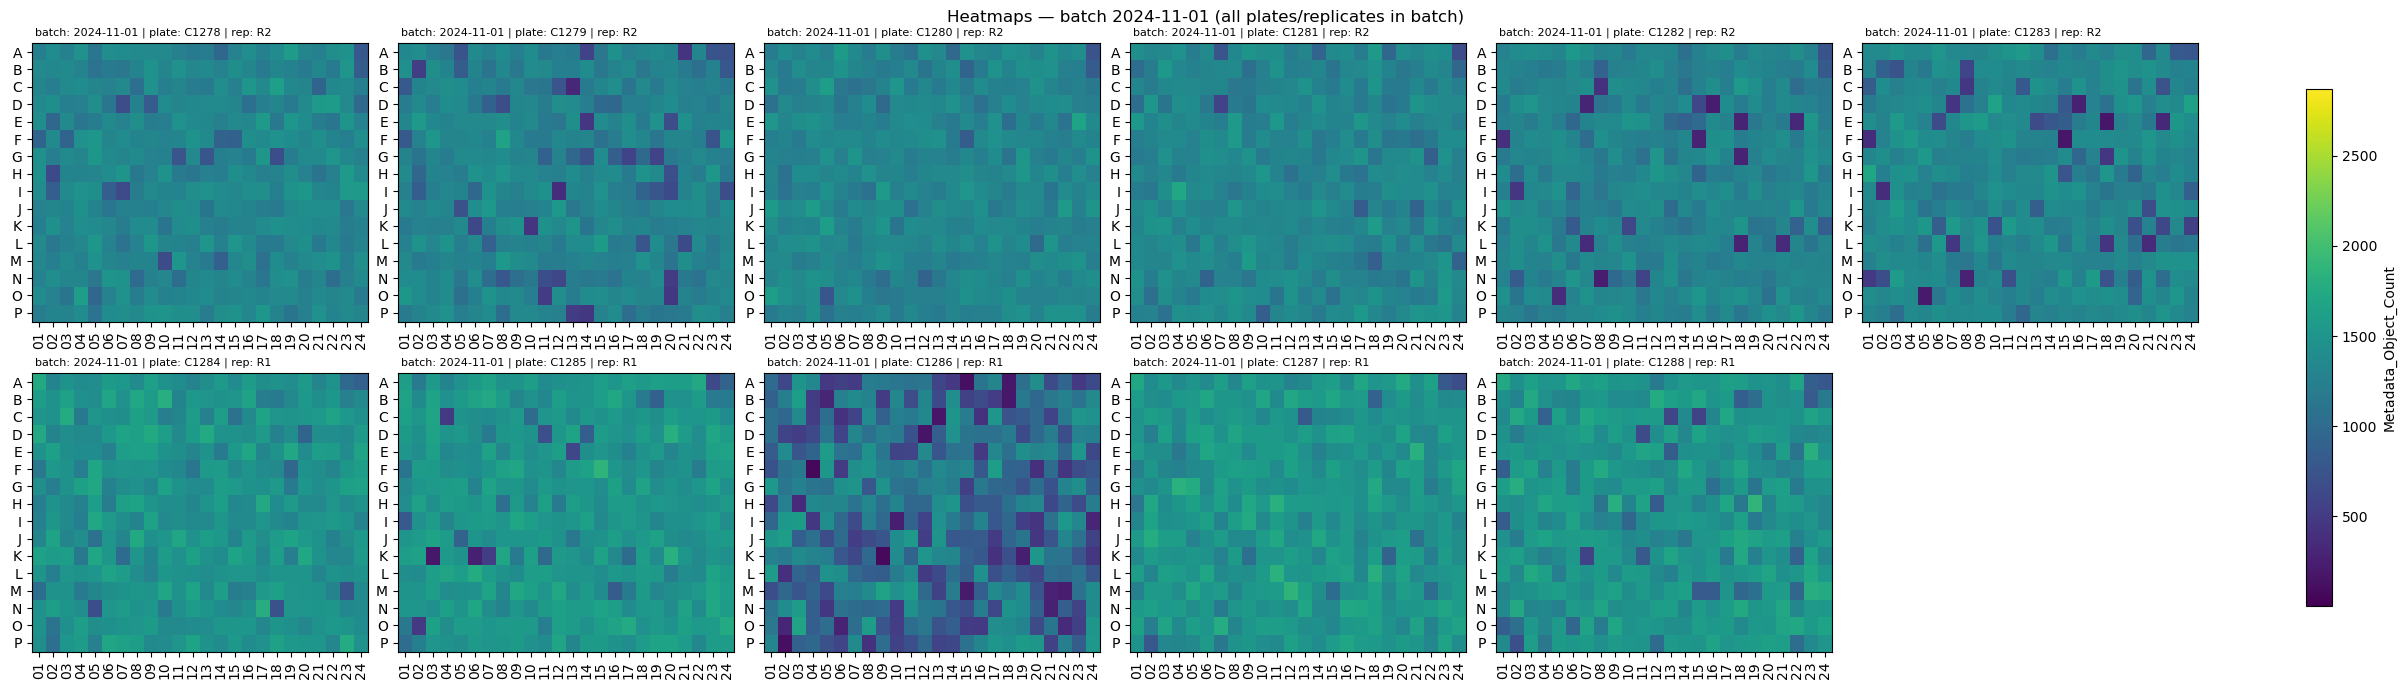

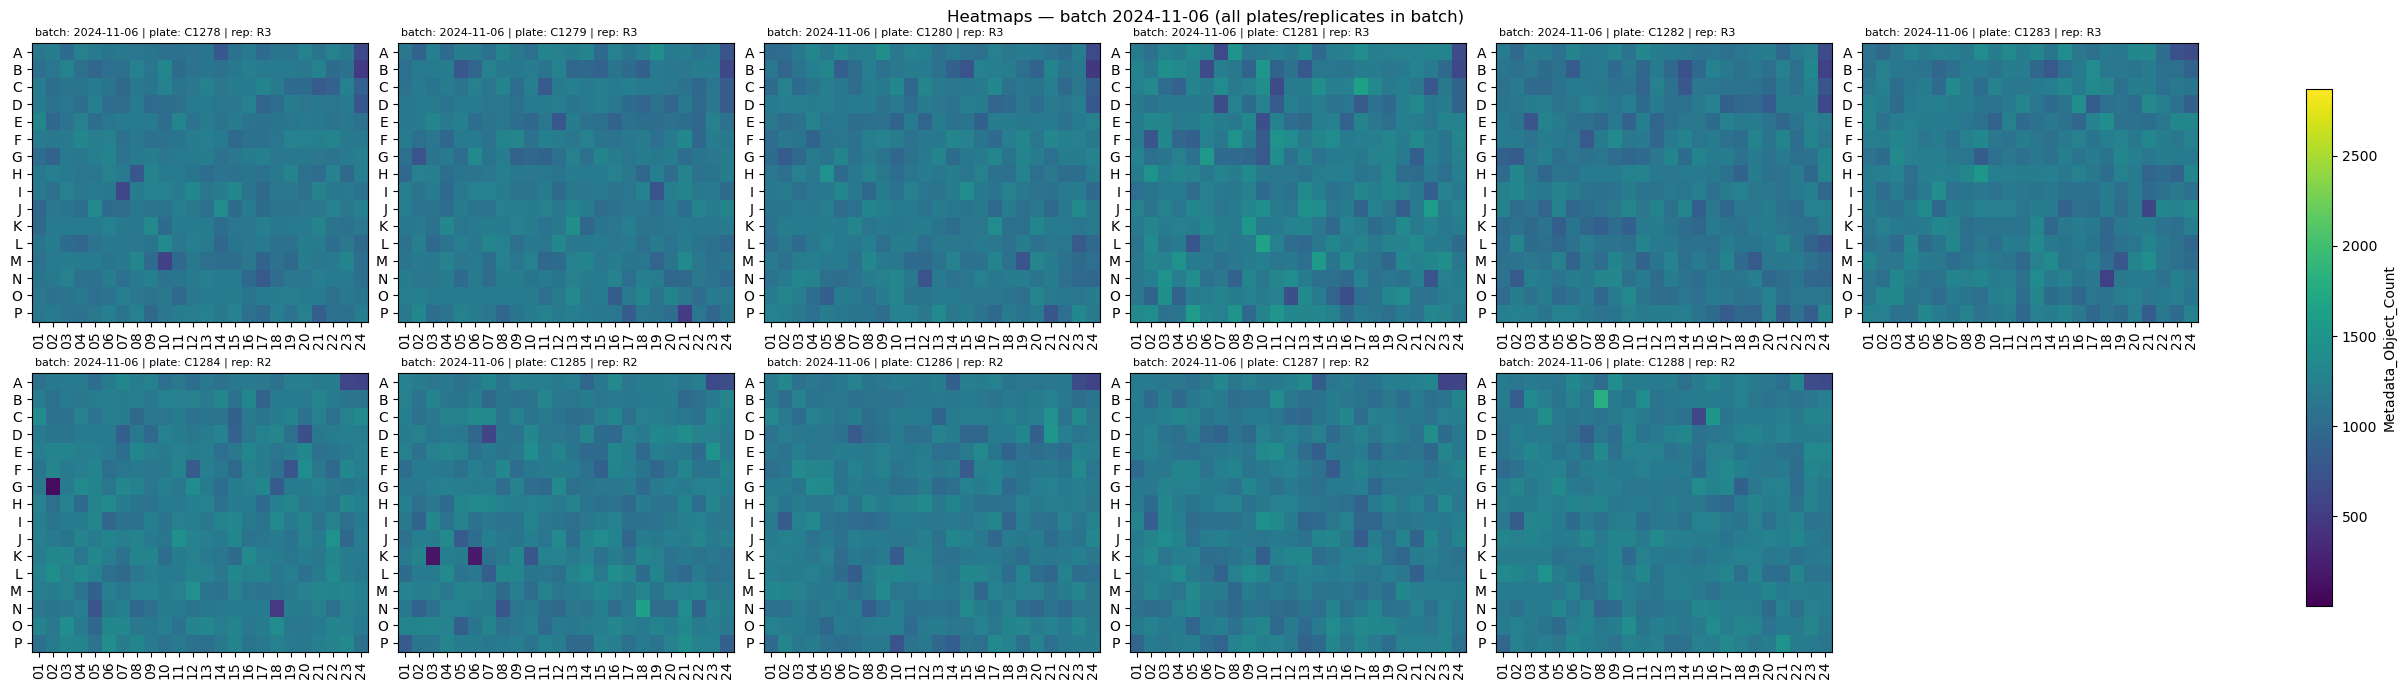

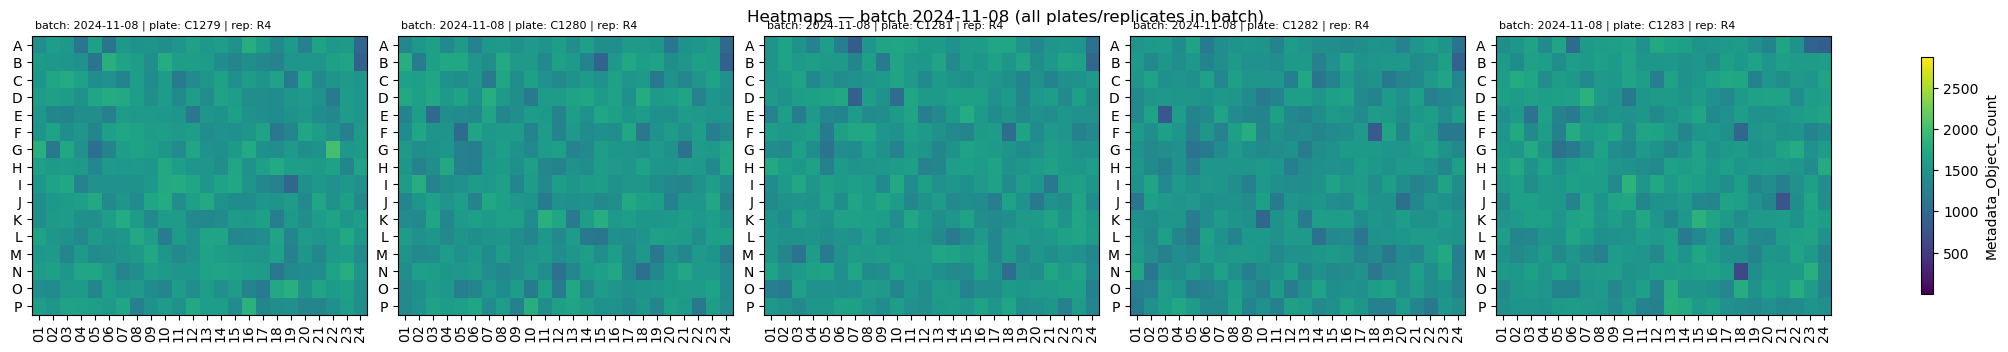

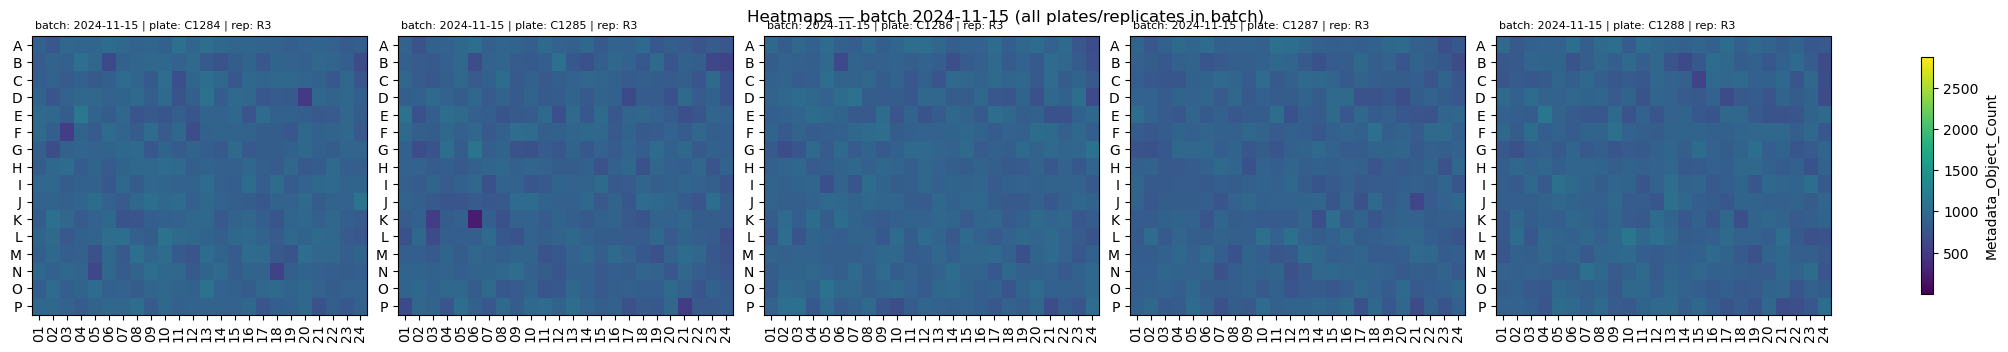

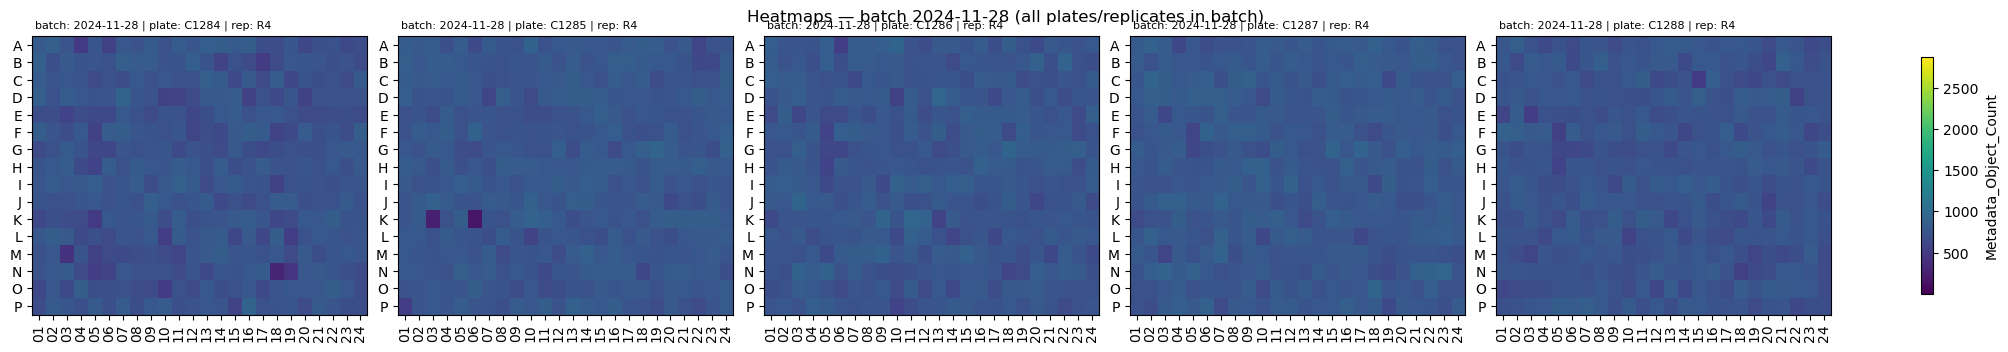

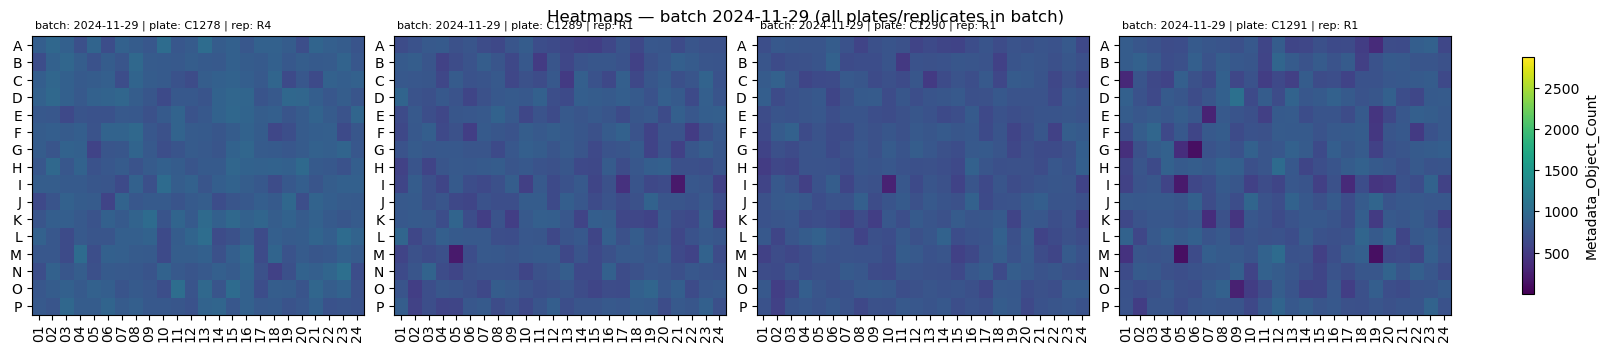

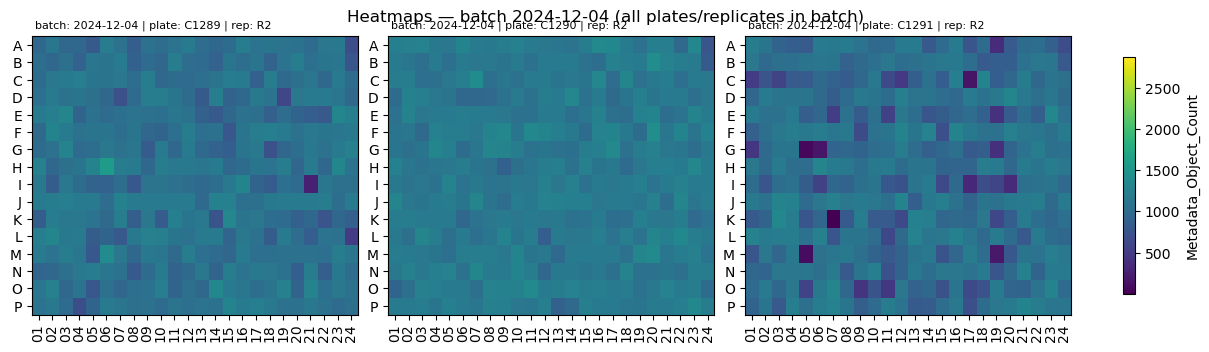

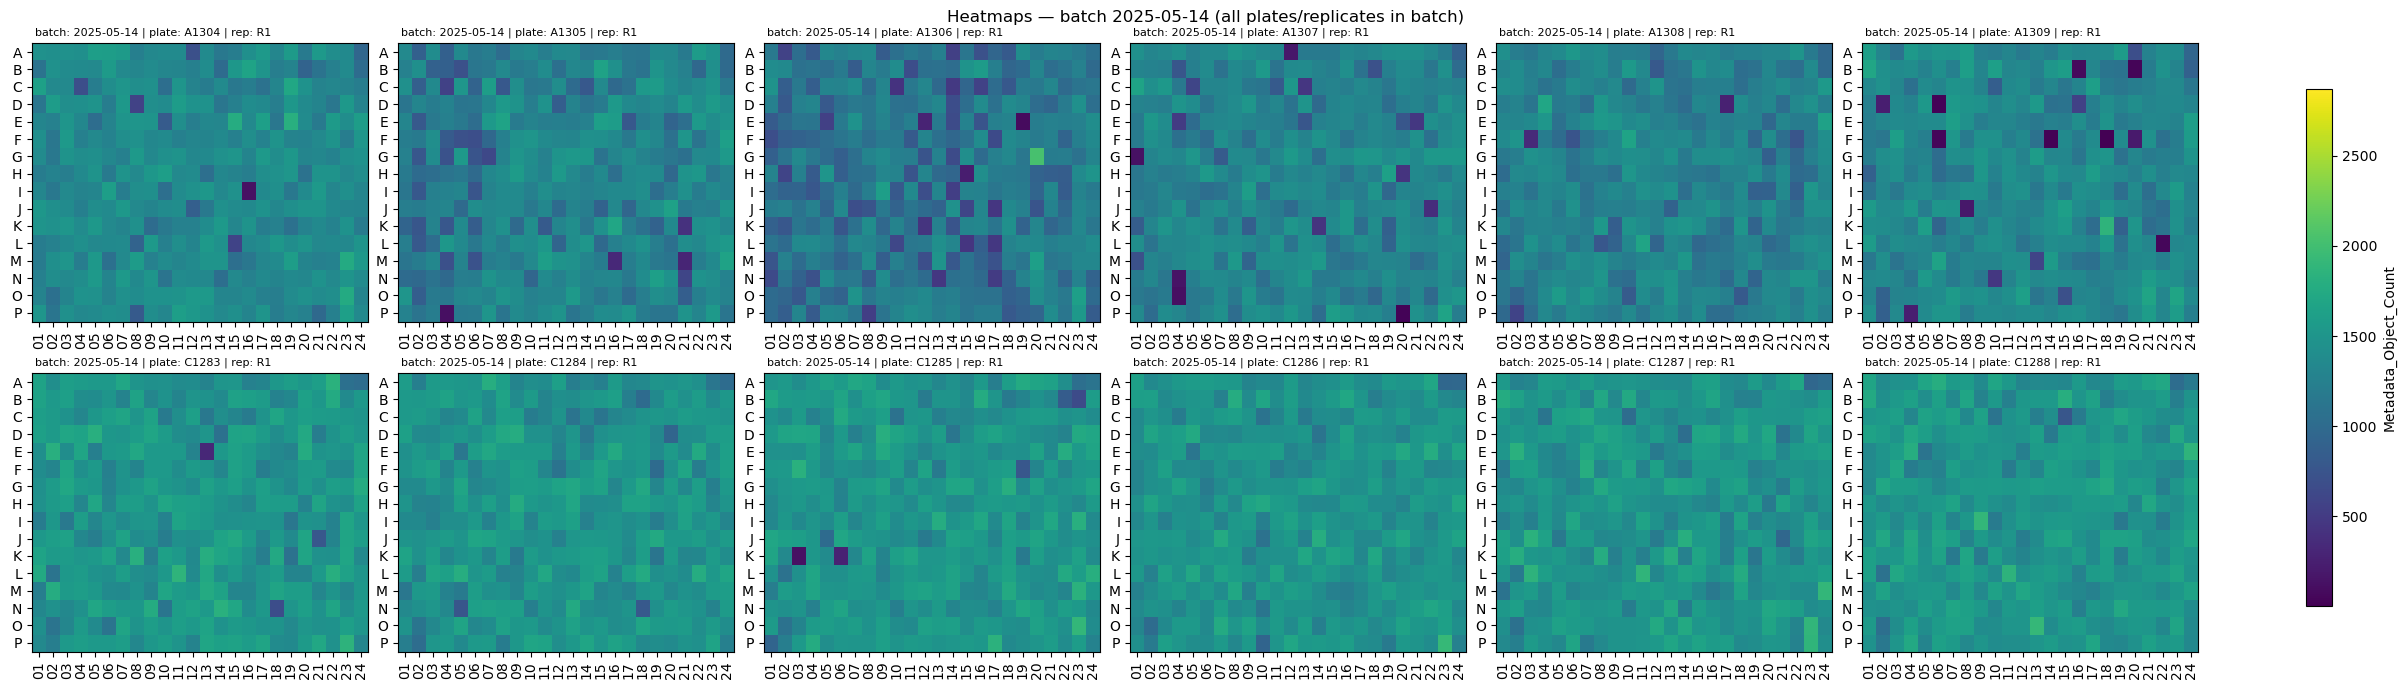

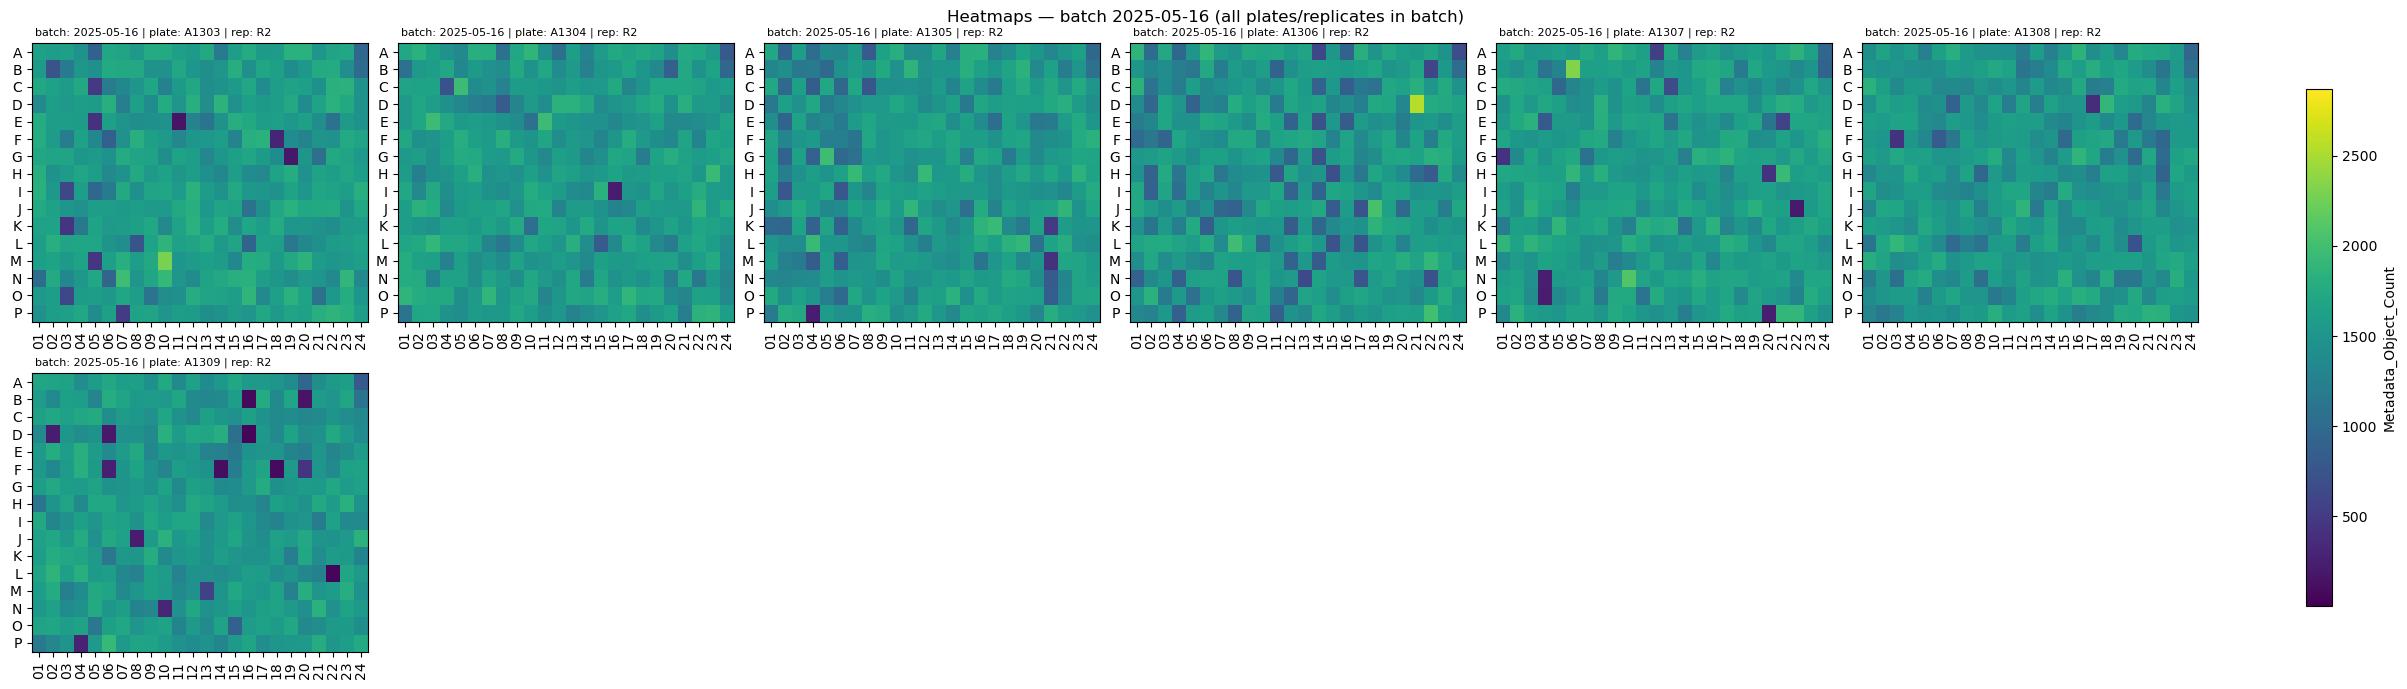

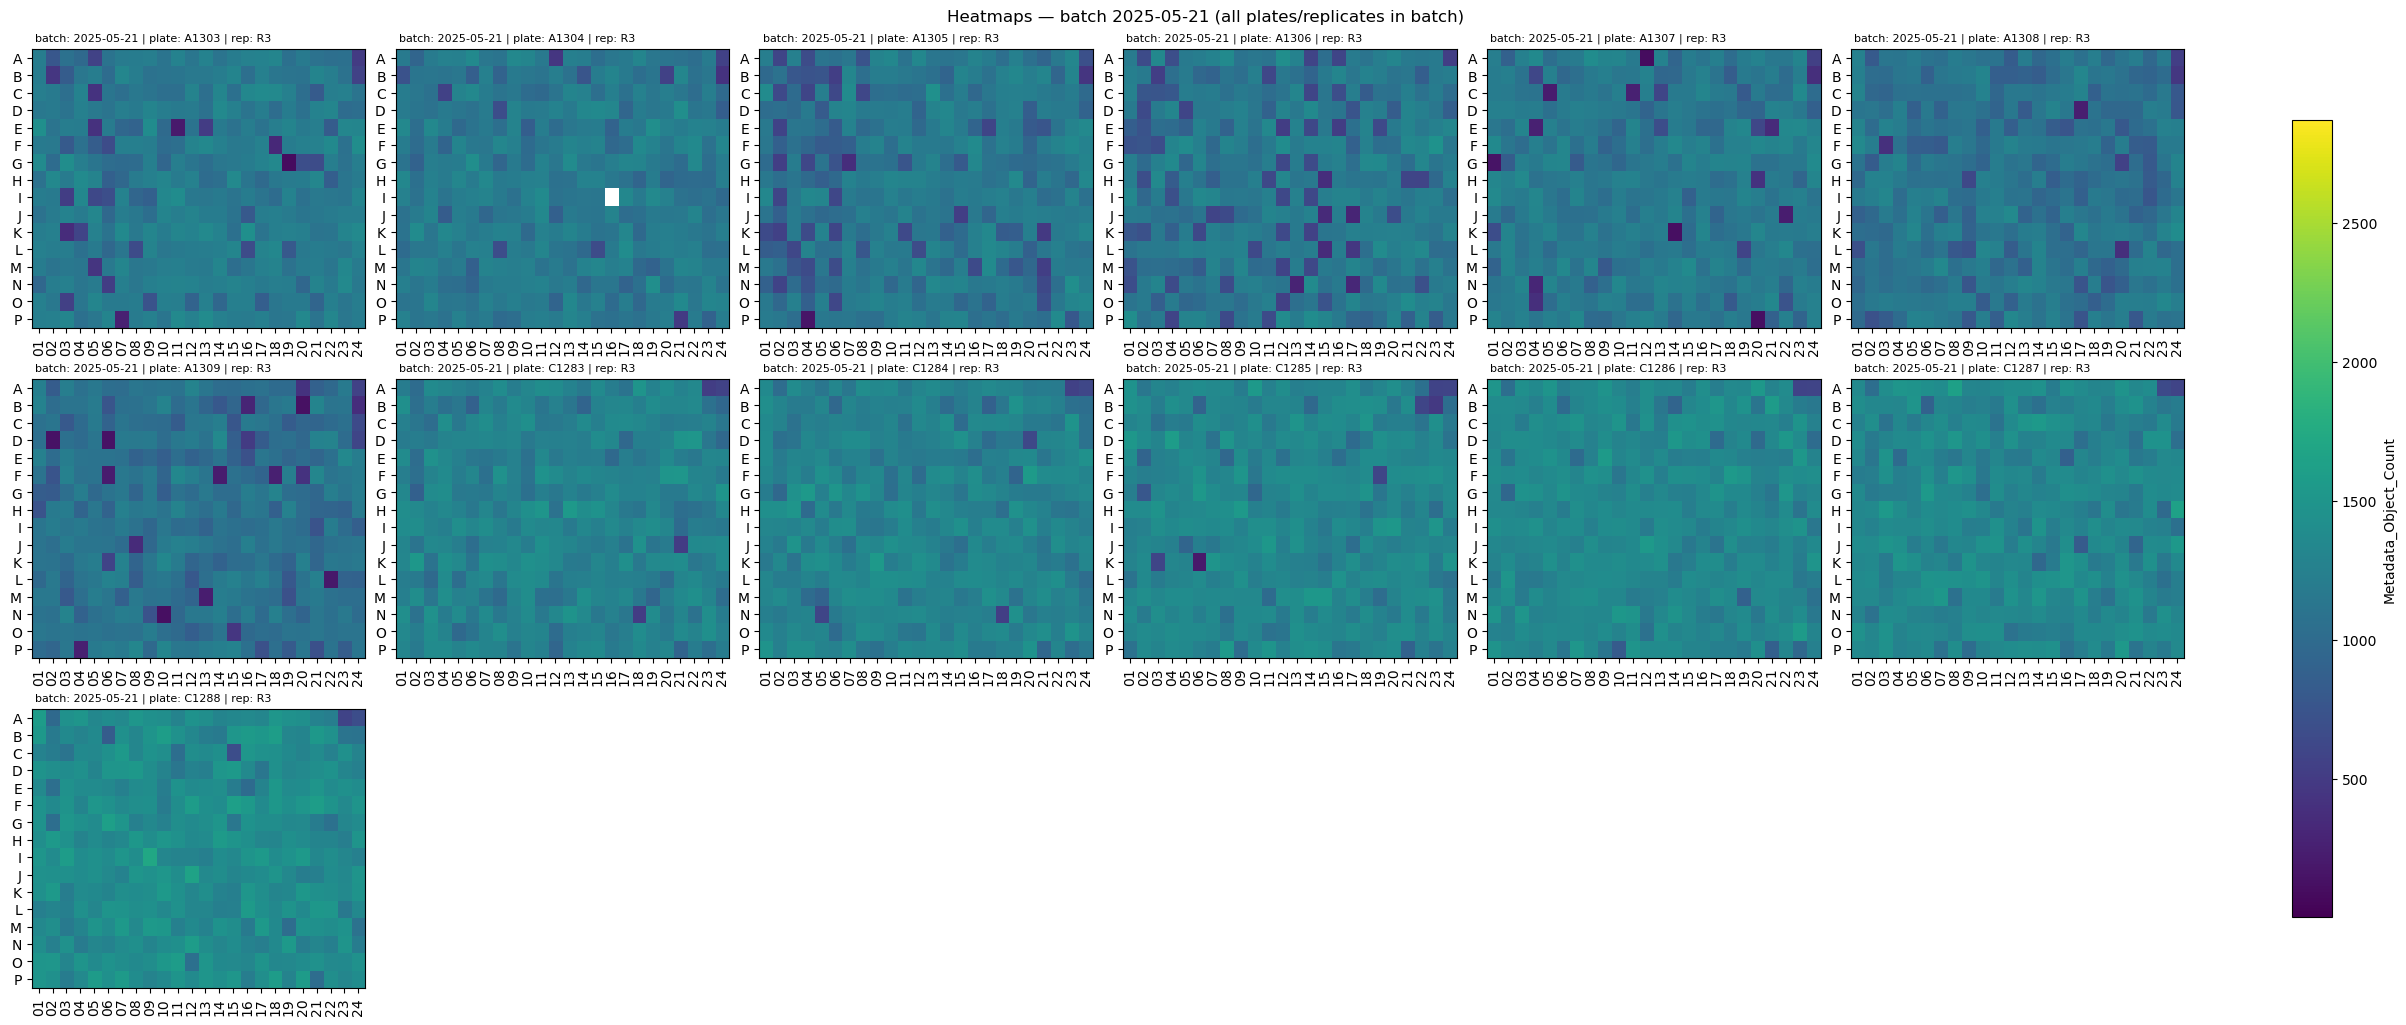

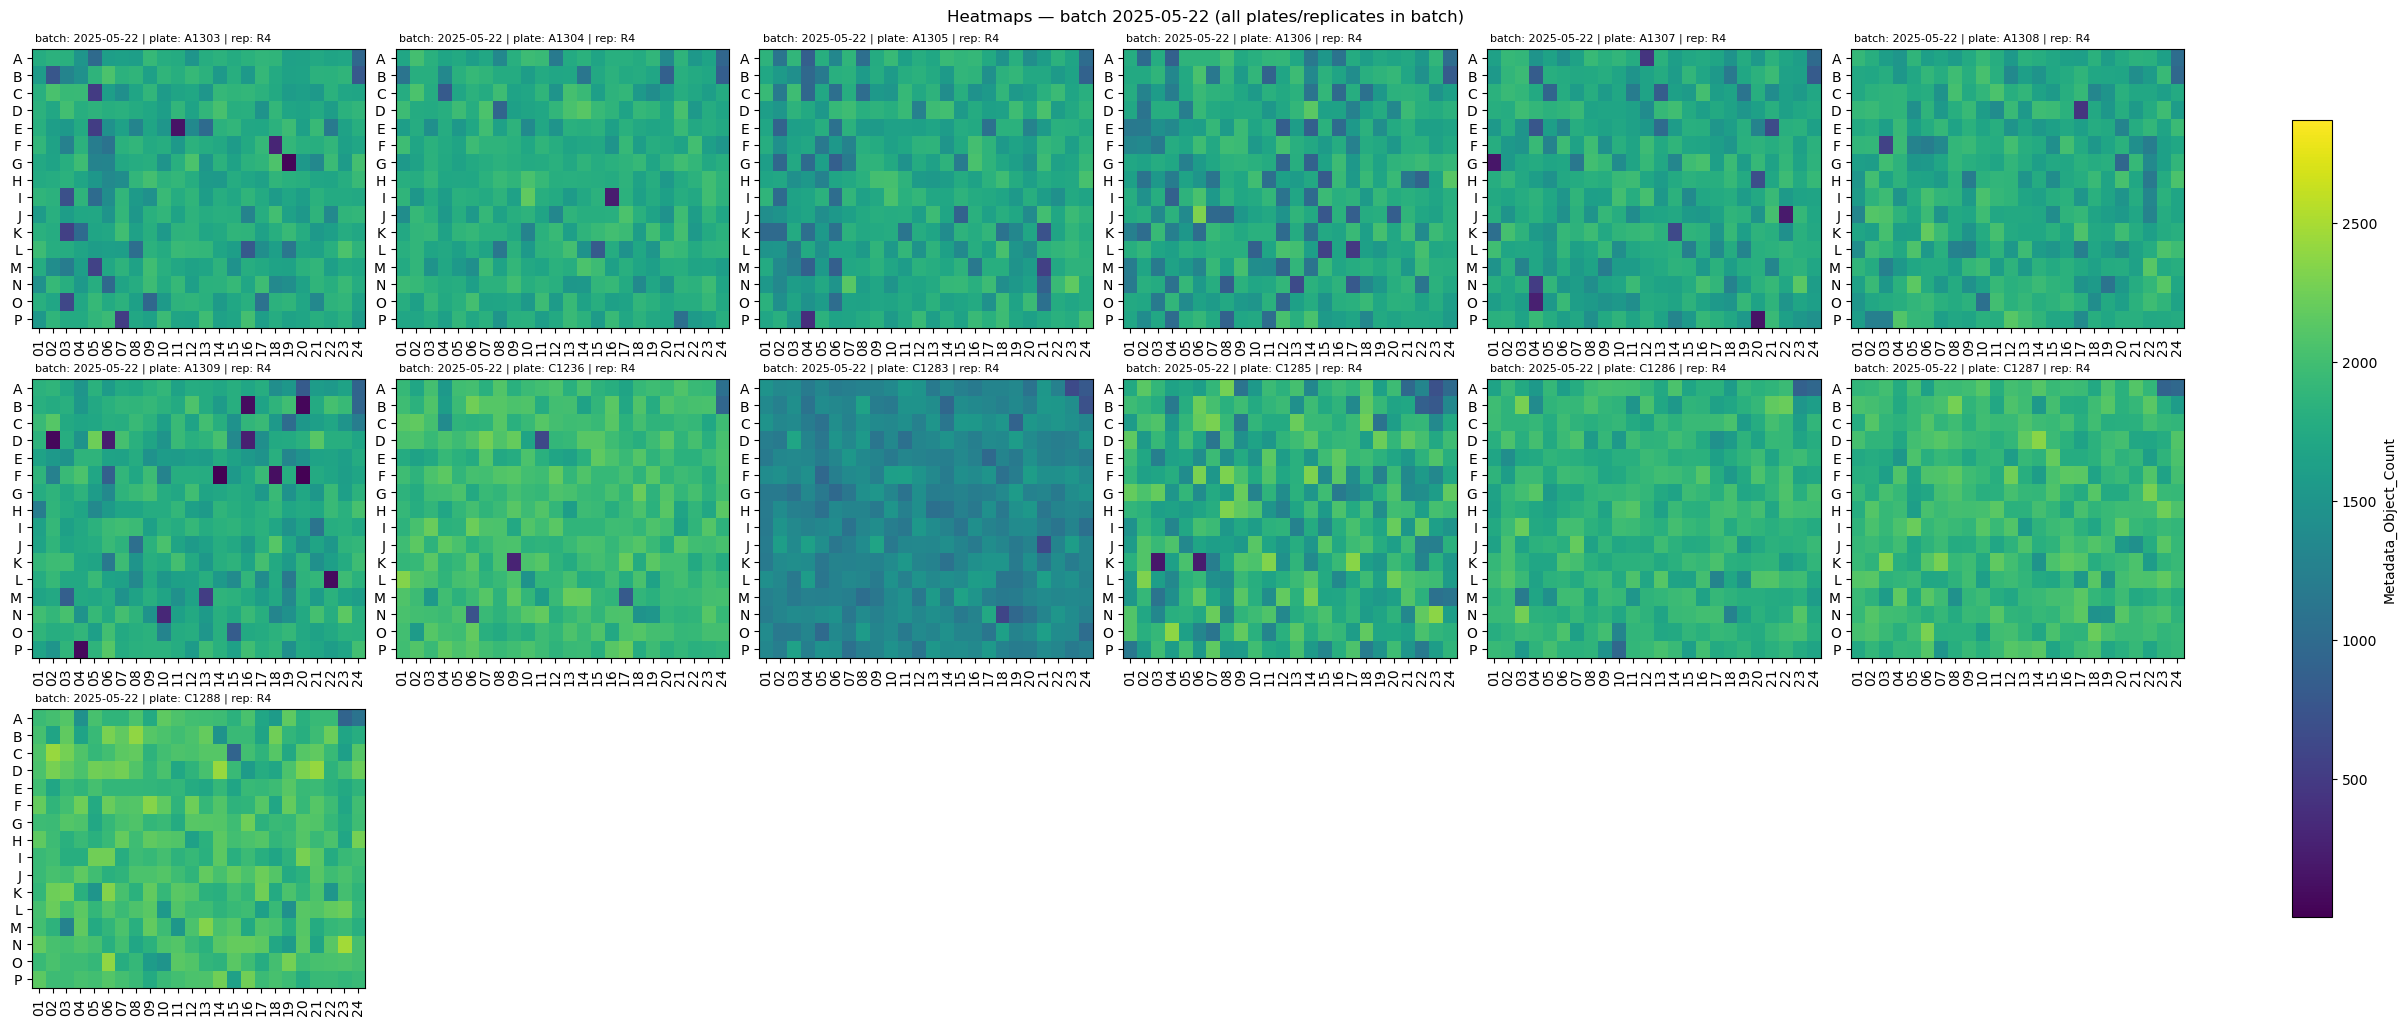

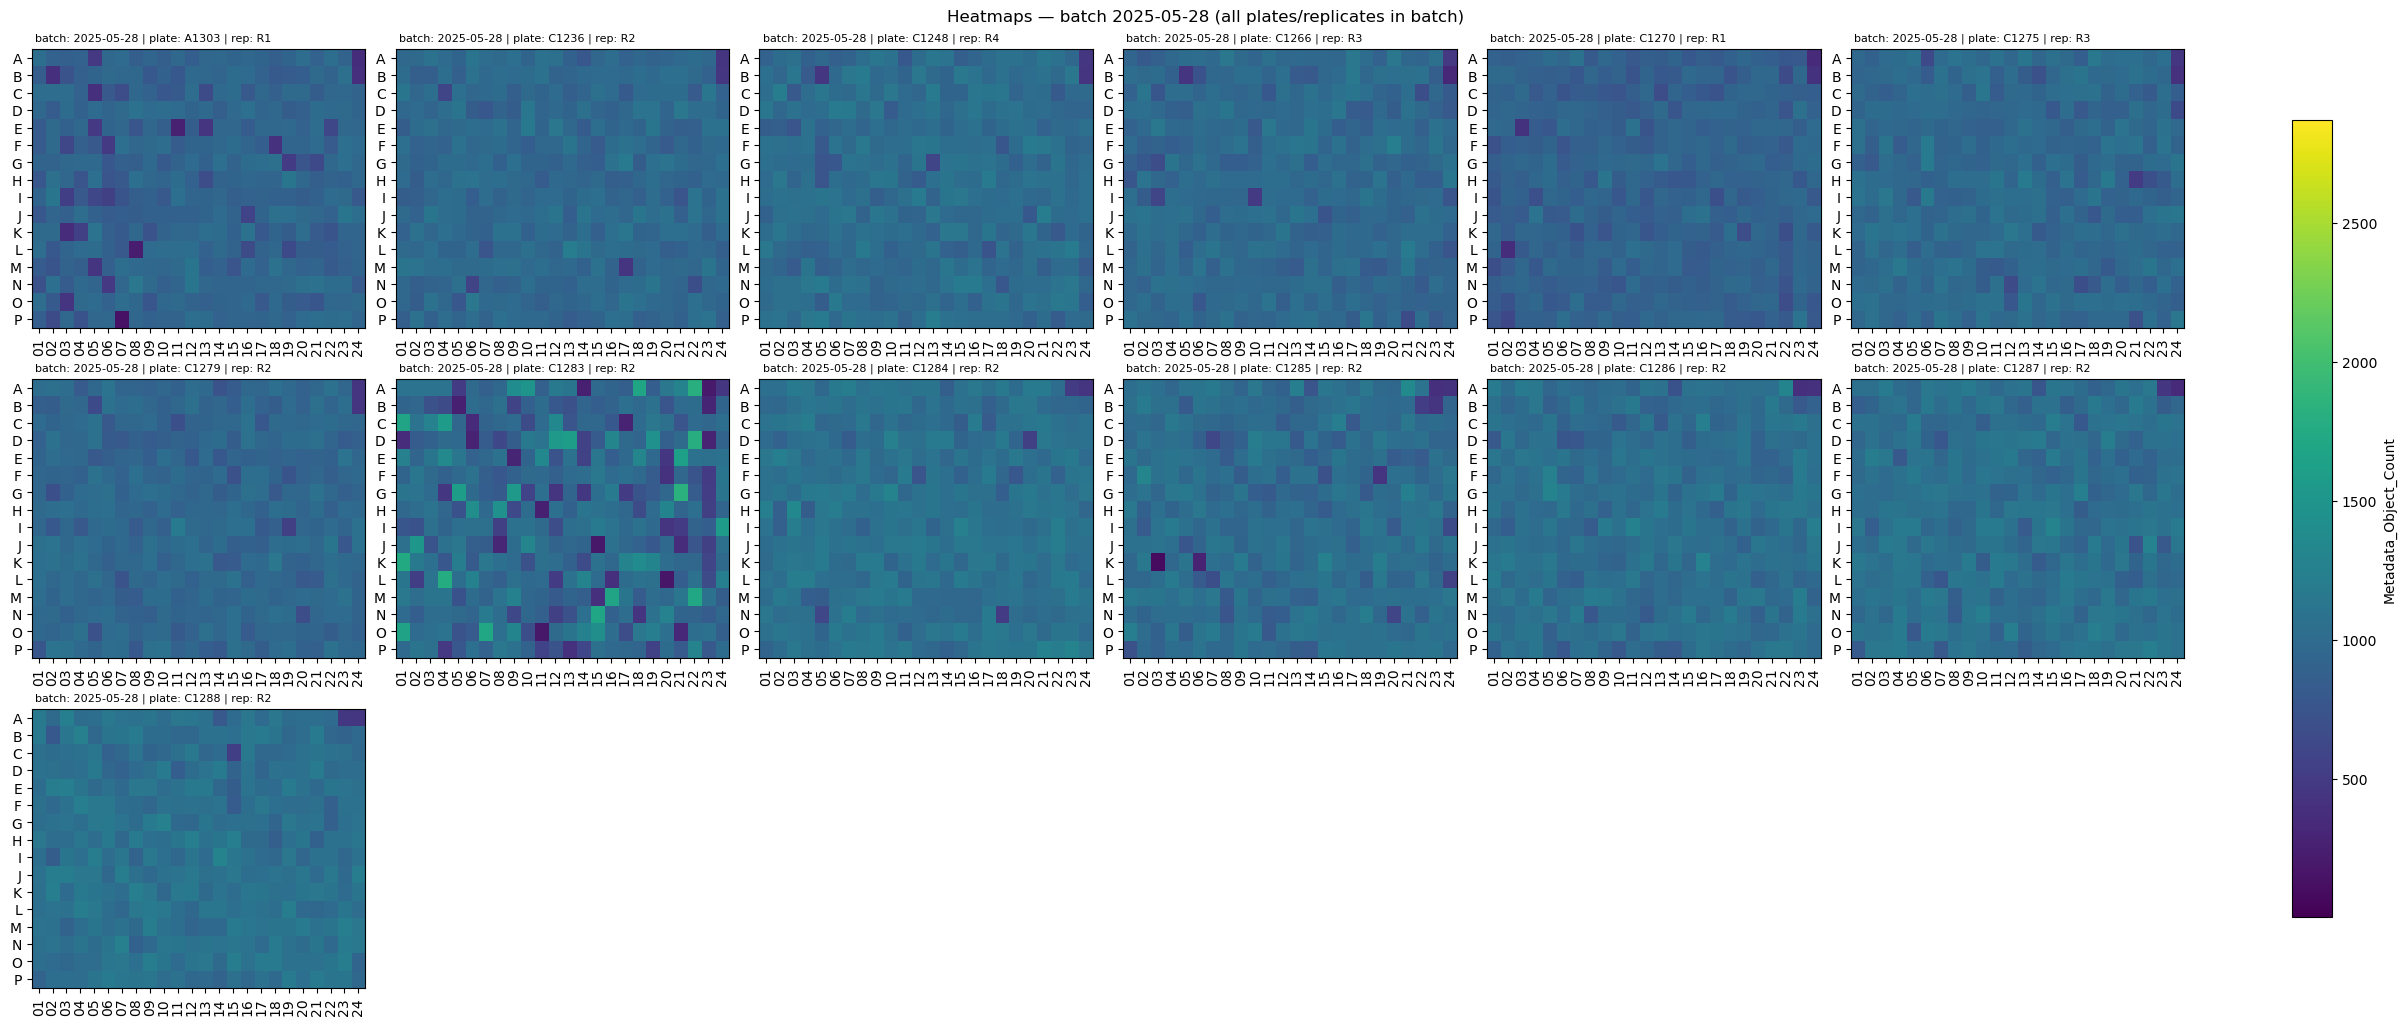

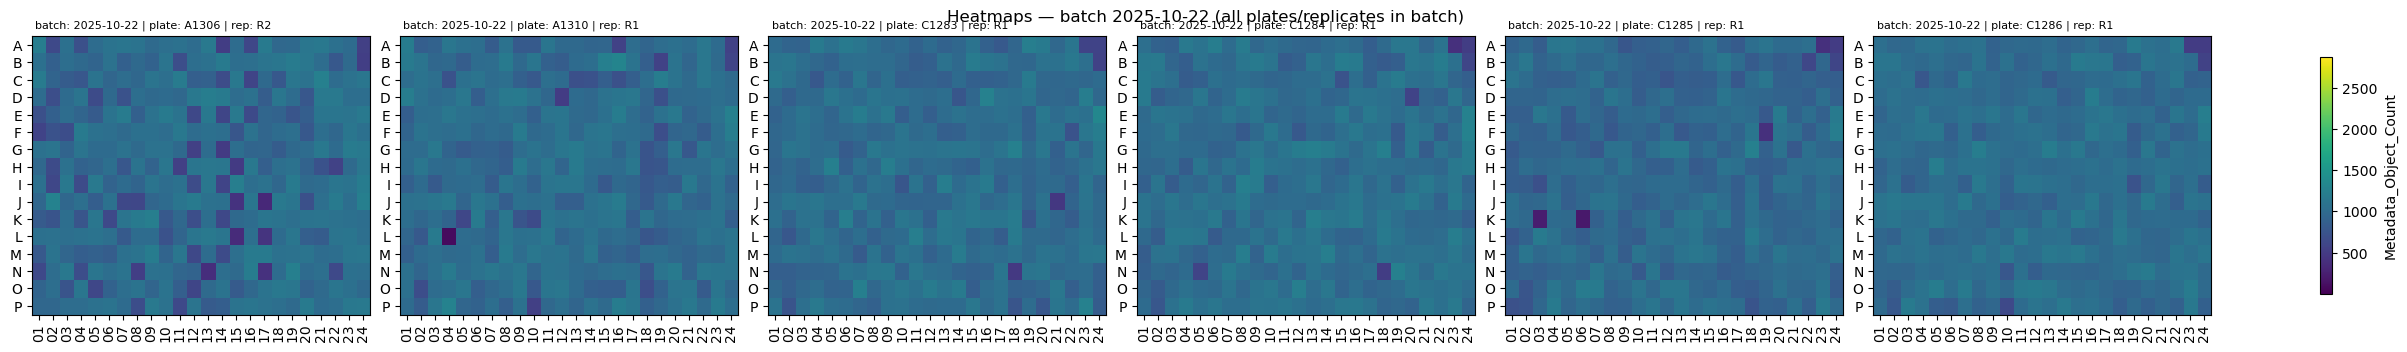

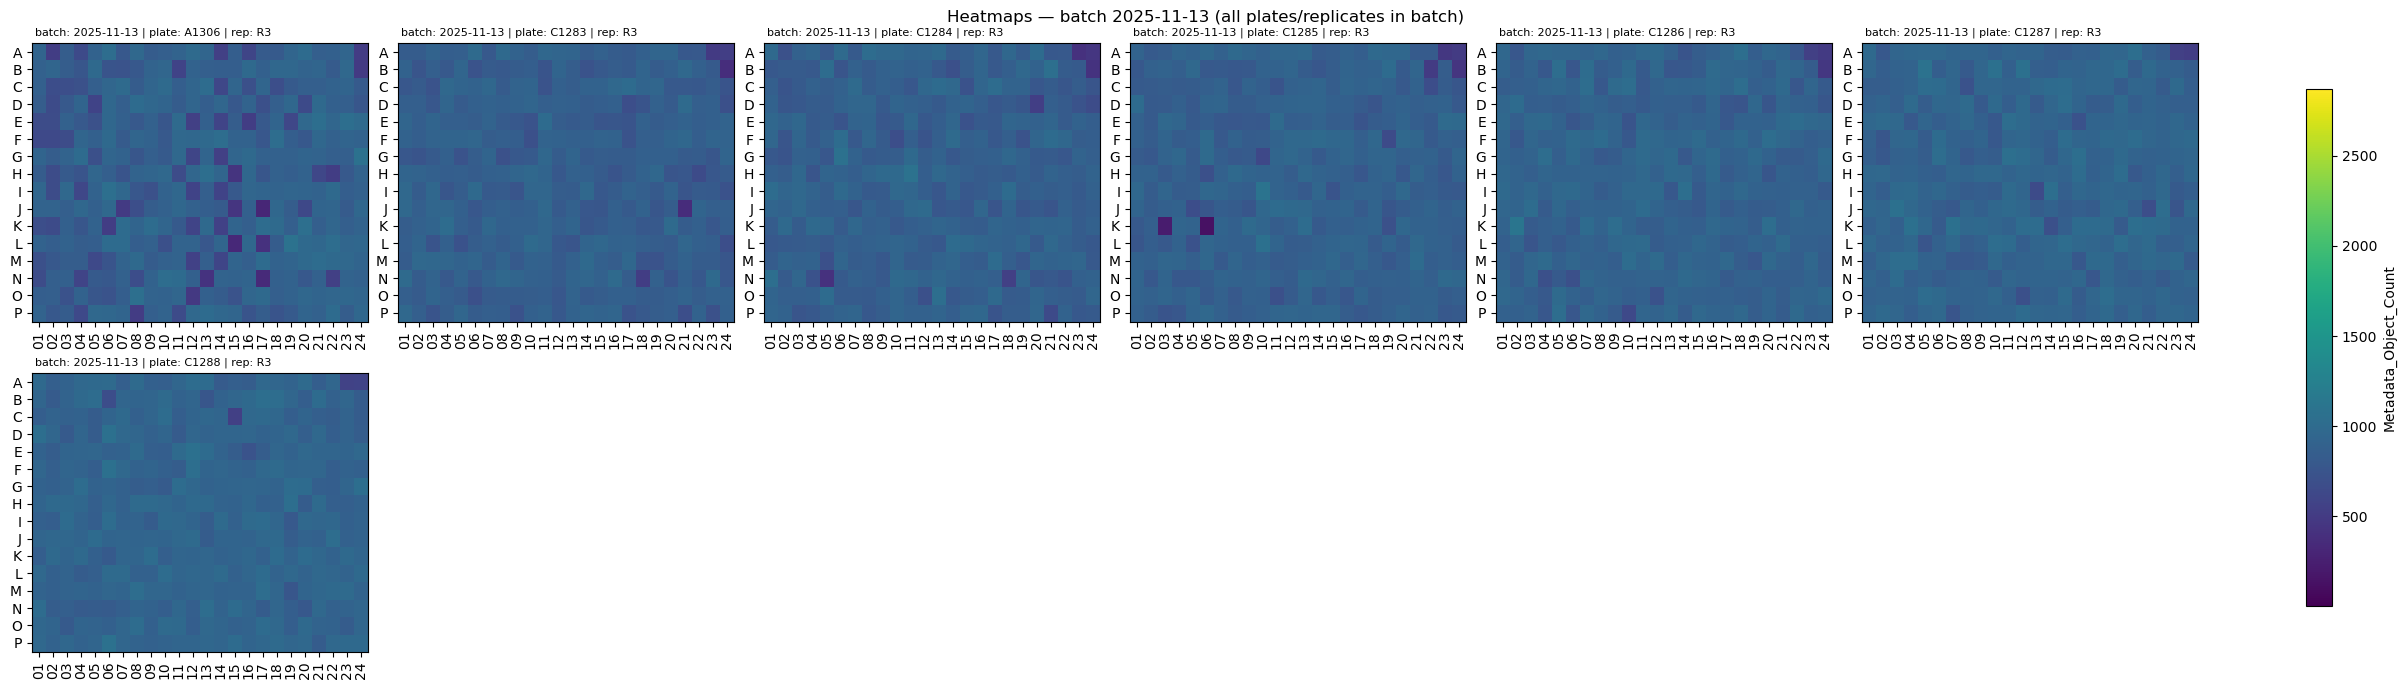

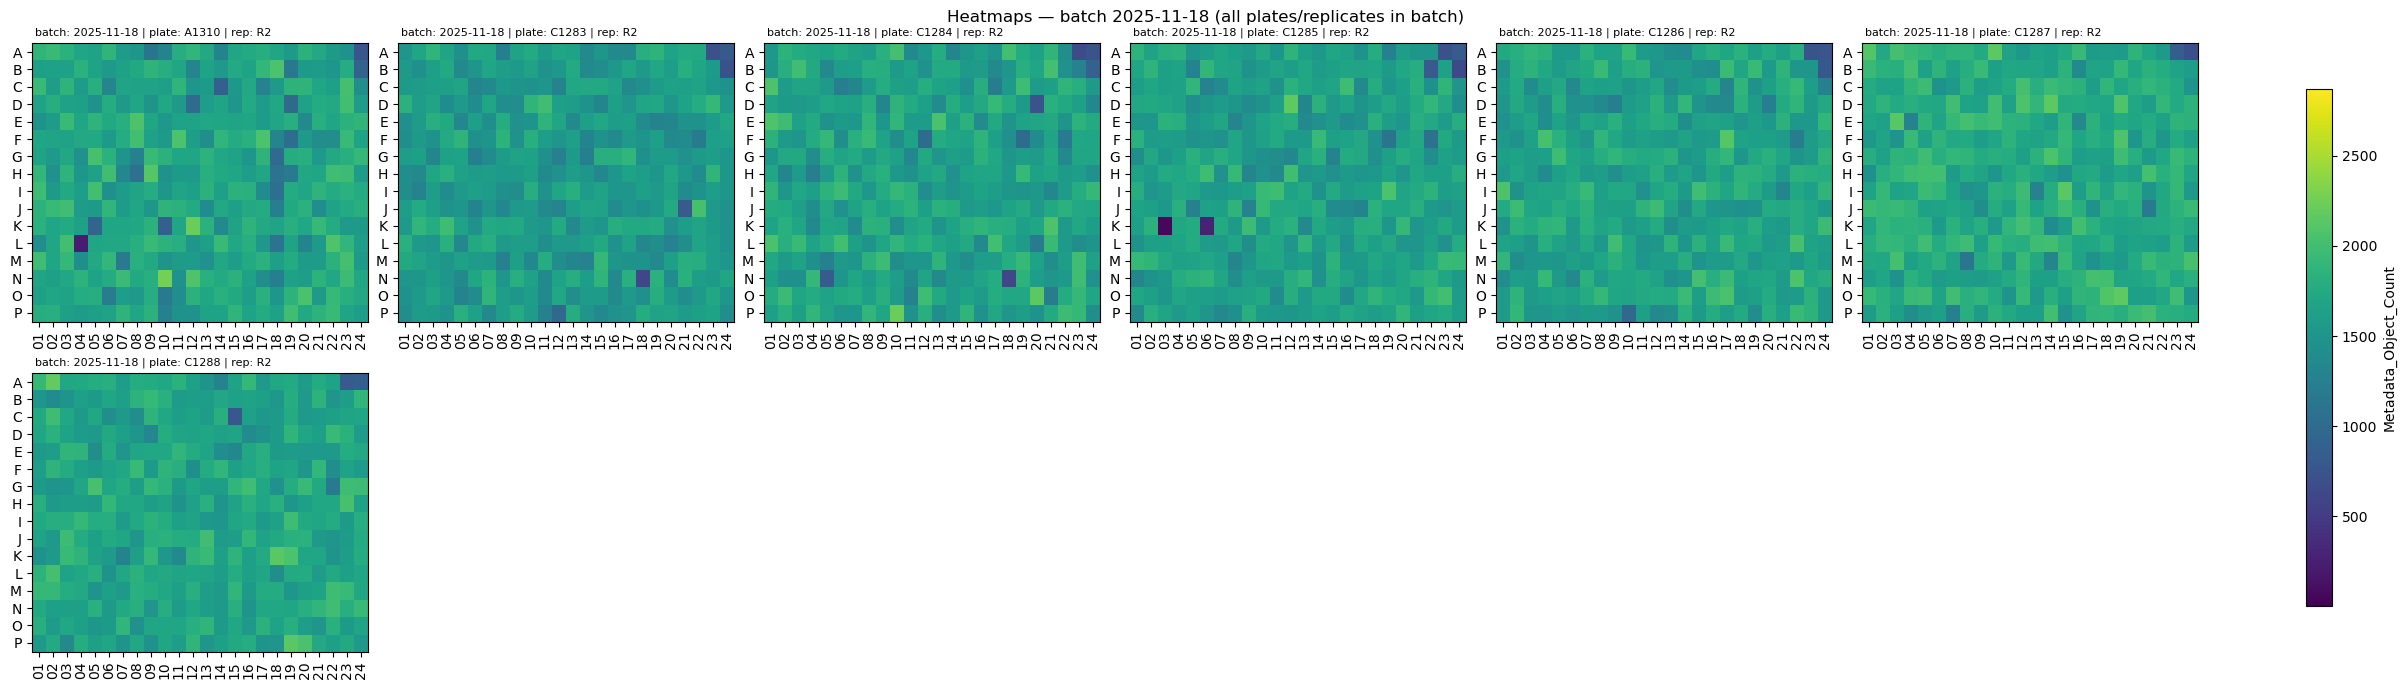

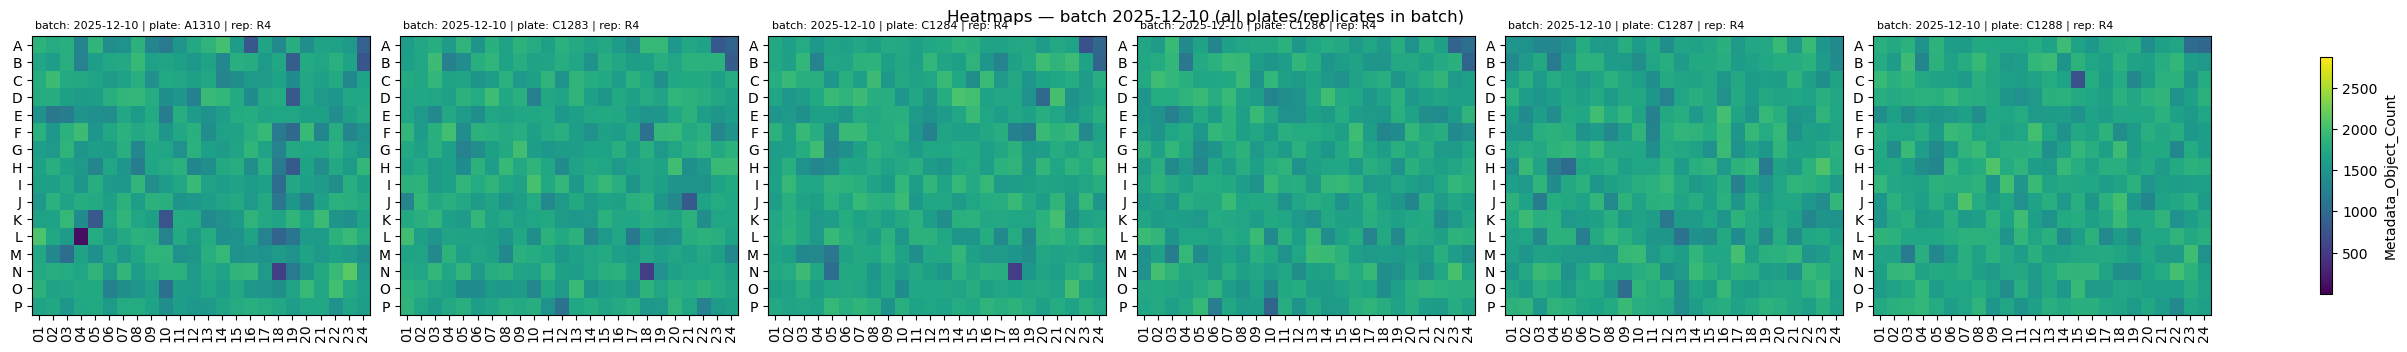

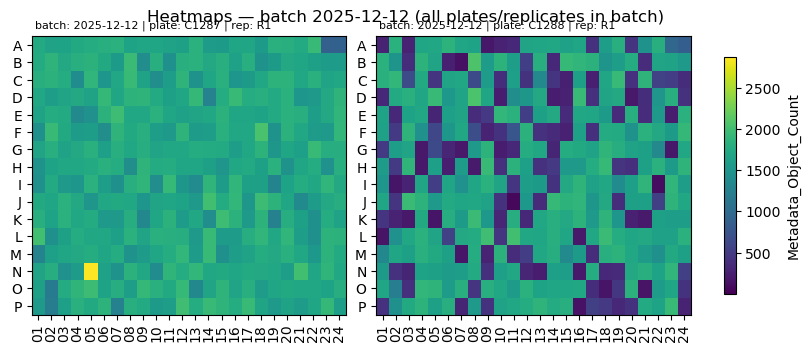

In [22]:
plot_plate_heatmaps_per_batch(batches_df,color_min,color_max)